# CorrelateGSWithPCF.ipynb

Produces correlation plots between the metabolic pathway definitions and the metabolic neighbourhood compositions with the gene-set enrichement using *singscore*.

Figure 2h is the primary output for the paper, as well as Supplementary Figure 2 and Supplementary Figure 3.

### Setup


`conda create -n analysis scipy numpy pandas anndata matplotlib`

`conda activate analysis`

`pip install PyComplexHeatmap`

In [ ]:
import scipy
import scipy.stats
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from PyComplexHeatmap import ClusterMapPlotter

In [ ]:
# Read the cleaned and CN-annotated AnnData object

adata = ad.read_h5ad(r'../adjTMA_xbounds_withCNs.h5ad')
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

In [ ]:
# Read the gene-set rank scores

df = pd.read_csv('ranked_singscore_wRelapse.csv')
roimap = pd.read_csv('ROI_patient_link.csv')
df['patientid'] = list(zip(df['TMA'], df['ROI']))
df['patientid'] = df['patientid'].map(roimap.set_index(['TMA', 'ROI']).to_dict()['Patient'])
df

,Unnamed: 0,ROI,Response,Segment,Histology,TMA,Name,Score,patientid
0,1,1,N,Tumour,Adenocarcinoma,TMA_A,GROSS_HYPOXIA_VIA_HIF1A_ONLY,0.224624,B16
1,2,1,N,Tumour,Adenocarcinoma,TMA_A,GROSS_HYPOXIA_VIA_ELK3_UP,0.179128,B16
2,3,1,N,Tumour,Adenocarcinoma,TMA_A,KEGG_GLYCOLYSIS_GLUCONEOGENESIS,0.127248,B16
3,4,1,N,Tumour,Adenocarcinoma,TMA_A,KEGG_CITRATE_CYCLE_TCA_CYCLE,0.258011,B16
4,5,1,N,Tumour,Adenocarcinoma,TMA_A,KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.094074,B16
...,...,...,...,...,...,...,...,...,...
859,860,30,Y,Stroma,Adenocarcinoma,TMA_B,KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.101412,B82
860,861,30,Y,Stroma,Adenocarcinoma,TMA_B,KEGG_FATTY_ACID_METABOLISM,0.074302,B82
861,862,30,Y,Stroma,Adenocarcinoma,TMA_B,KEGG_OXIDATIVE_PHOSPHORYLATION,0.251526,B82
862,863,30,Y,Stroma,Adenocarcinoma,TMA_B,GOBP_GLUTAMINE_TRANSPORT,0.032628,B82


In [ ]:
#Ensure the Gene-Sets are present

df['Name'].unique()

array(['GROSS_HYPOXIA_VIA_HIF1A_ONLY', 'GROSS_HYPOXIA_VIA_ELK3_UP',
       'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_CITRATE_CYCLE_TCA_CYCLE',
       'KEGG_PENTOSE_PHOSPHATE_PATHWAY', 'KEGG_FATTY_ACID_METABOLISM',
       'KEGG_OXIDATIVE_PHOSPHORYLATION', 'GOBP_GLUTAMINE_TRANSPORT',
       'GOBP_RESPONSE_TO_OXIDATIVE_STRESS'], dtype=object)

In [ ]:
# Map the cell types to be common with the GeoMx Segments

adata_geomx_overlaps = adata[adata.obs.patientID.isin(df['patientid'].unique())]
adata_geomx_overlaps.obs['broad_cellsegment'] = adata_geomx_overlaps.obs['base_celltypes'].map({'Tumour': 'Tumour', 'Macrophages': 'Stroma', 'B_cells': 'Stroma', \
                                                                                                'CD4_cells': 'Stroma', 'CD8_cells': 'Stroma', 'Fibroblast': 'Stroma', 'Other_Stromal_cells': 'Stroma', 'Vessels': 'Stroma'})

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_59335/3008405094.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_geomx_overlaps.obs['broad_cellsegment'] = adata_geomx_overlaps.obs['base_celltypes'].map({'Tumour': 'Tumour', 'Macrophages': 'Stroma', 'B_cells': 'Stroma', \


In [ ]:
# Remove underscores from the names

adata_geomx_overlaps.obs['Metabolic'] = [(a.replace('Lipid_Oxidation', 'LipidOxidation')).replace('Glutamine_import', 'GlutamineImport').replace('Oxidative_Stress', 'OxidativeStress')\
                                          for a in adata_geomx_overlaps.obs.Metabolic_allcells]

In [ ]:
# Wide-form the metabolic labels

adata_geomx_overlaps.obs['PPP'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('PPP')
adata_geomx_overlaps.obs['GlutamineImport'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('GlutamineImport')
adata_geomx_overlaps.obs['MetaLow'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('Phenotype')
adata_geomx_overlaps.obs['LipidOxidation'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('LipidOxidation')
adata_geomx_overlaps.obs['Hypoxic'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('Hypoxic')
adata_geomx_overlaps.obs['OxPhos'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('OxPhos')
adata_geomx_overlaps.obs['OxidativeStress'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('OxidativeStress')
adata_geomx_overlaps.obs['Mitochondrial'] = adata_geomx_overlaps.obs['Metabolic'].str.contains('Mitochondrial')

In [ ]:
# Assert the pathway definitions for plotting

pathways = {
    "Glycolytic Metabolism":    [{'marker': 'GLUT1', 'Directionality': 1}, {'marker': 'Hexokinase1', 'Directionality': 1},
                                 {'marker': 'CITRATE SYNTHASE', 'Directionality': 0}, {'marker': 'ATPA5', 'Directionality': 0},
                                 {'marker': 'SDHA', 'Directionality': 0}, 
                                ],
    "OxPhos Metabolism":        [{'marker': 'CITRATE SYNTHASE', 'Directionality': 1}, {'marker': 'ATPA5', 'Directionality': 1},
                                 {'marker': 'SDHA', 'Directionality': 1},
                                ],
    "Mitochondrial Metabolism": [{'marker': 'CITRATE SYNTHASE', 'Directionality': 1}, {'marker': 'ATPA5', 'Directionality': 1},
                                 {'marker': 'SDHA', 'Directionality': 1}, {'marker': 'CPT1A', 'Directionality': 1},
                                 {'marker': 'ASCT2', 'Directionality': 1},
                                ],
    "Oxidative Stress":         [{'marker': 'pNRF2', 'Directionality': 1}, {'marker': 'SDHA', 'Directionality': 0}, 
                                 {'marker': 'CPT1A', 'Directionality': 1},
                                ],
    "Lipid Oxidation":          [{'marker': 'CPT1A', 'Directionality': 1},
                                ],   
    "Glutamine Import":         [{'marker': 'ASCT2', 'Directionality': 1},
                                ],   
    "PPP":                      [{'marker': 'G6PD', 'Directionality': 1},
                                ],   
}

In [ ]:
# Compute the normalised log1p expression

def compute_expression(adata_, pathway, pathway_dict):
    additives = []
    for marker_schema in pathway_dict[pathway]:
        additive = adata_.obsm['marker_expression'][marker_schema['marker']]
        if marker_schema['Directionality'] == 0:
            additive = additive
        else:
            additive = marker_schema['Directionality']*additive

        additives.append(additive)
    additives = pd.DataFrame(pd.DataFrame(additives).T.mean(1), columns=[f'{pathway}_expression'])
    return additives

def compute_all_pathway_scores(adata_, pathway_dict):
    df_ = []
    for pathway, stuff in pathway_dict.items():
        expression = compute_expression(adata_, pathway, pathway_dict)
        df_.append(expression)

    df_ = pd.concat(df_, axis=1)

    return df_

adata_geomx_overlaps.obsm['marker_expression'] = pd.DataFrame(adata_geomx_overlaps.X, index=adata_geomx_overlaps.obs.index, columns = adata_geomx_overlaps.var_names)
adata_geomx_overlaps.obsm['marker_expression'] /= adata_geomx_overlaps.obsm['marker_expression'].max(0)
adata_geomx_overlaps.obsm['marker_expression'] = adata_geomx_overlaps.obsm['marker_expression'].apply(np.log1p)
allscores = compute_all_pathway_scores(adata_geomx_overlaps, pathways)
adata_geomx_overlaps.obs = pd.concat([adata_geomx_overlaps.obs, allscores], axis=1)

In [ ]:
# Compute pseudobulk positiviey mean

df_pcf = adata_geomx_overlaps.obs[['patientID', 'broad_cellsegment', 'Glycolytic Metabolism_expression', 'OxPhos Metabolism_expression', 'Mitochondrial Metabolism_expression', 
                                   'Oxidative Stress_expression', 'Lipid Oxidation_expression', 'Glutamine Import_expression', 'PPP_expression']].groupby(by=['patientID', 'broad_cellsegment']).mean().reset_index()

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_59335/4020204896.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Oxidative Stress_expression', 'Lipid Oxidation_expression', 'Glutamine Import_expression', 'PPP_expression']].groupby(by=['patientID', 'broad_cellsegment']).mean().reset_index()


In [ ]:
# Pivot and Rename

df_geomx = df.pivot(index=['patientid', 'Segment'], columns='Name', values='Score')
df_geomx.columns = ['GeoMx:' + a for a in df_geomx.columns]
df_geomx= df_geomx.reset_index()
df_geomx 

,patientid,Segment,GeoMx:GOBP_GLUTAMINE_TRANSPORT,GeoMx:GOBP_RESPONSE_TO_OXIDATIVE_STRESS,GeoMx:GROSS_HYPOXIA_VIA_ELK3_UP,GeoMx:GROSS_HYPOXIA_VIA_HIF1A_ONLY,GeoMx:KEGG_CITRATE_CYCLE_TCA_CYCLE,GeoMx:KEGG_FATTY_ACID_METABOLISM,GeoMx:KEGG_GLYCOLYSIS_GLUCONEOGENESIS,GeoMx:KEGG_OXIDATIVE_PHOSPHORYLATION,GeoMx:KEGG_PENTOSE_PHOSPHATE_PATHWAY
0,B11,Stroma,0.014131,0.120846,0.172359,0.177889,0.189116,0.076819,0.115970,0.265719,0.138624
1,B11,Tumour,0.020322,0.110501,0.162873,0.127538,0.241993,0.076802,0.114778,0.276645,0.163020
2,B12,Stroma,0.008898,0.092101,0.159811,-0.000368,0.151330,0.050875,0.078579,0.248727,0.022853
3,B12,Tumour,0.036832,0.090653,0.156965,0.056225,0.218971,0.102725,0.122005,0.282634,0.151772
4,B14,Tumour,-0.008022,0.103345,0.175323,0.162579,0.209223,0.071364,0.139729,0.258834,0.173991
...,...,...,...,...,...,...,...,...,...,...,...
91,B83,Tumour,0.026824,0.099684,0.145214,0.121357,0.172515,0.124603,0.134973,0.267543,0.144641
92,B85,Stroma,0.023978,0.096372,0.134457,0.158969,0.137442,0.049258,0.099833,0.243419,0.078791
93,B85,Tumour,0.099249,0.098904,0.151732,0.097213,0.263514,0.084833,0.138203,0.278725,0.140845
94,B88,Stroma,-0.068094,0.098520,0.135177,0.117251,0.123277,0.027638,0.106368,0.225537,0.084377


In [ ]:
# Merge the dataframes

merged = pd.merge(df_geomx, df_pcf, left_on=['patientid', 'Segment'], right_on=['patientID', 'broad_cellsegment']).set_index(['patientid', ])
merged

,Segment,GeoMx:GOBP_GLUTAMINE_TRANSPORT,GeoMx:GOBP_RESPONSE_TO_OXIDATIVE_STRESS,GeoMx:GROSS_HYPOXIA_VIA_ELK3_UP,GeoMx:GROSS_HYPOXIA_VIA_HIF1A_ONLY,GeoMx:KEGG_CITRATE_CYCLE_TCA_CYCLE,GeoMx:KEGG_FATTY_ACID_METABOLISM,GeoMx:KEGG_GLYCOLYSIS_GLUCONEOGENESIS,GeoMx:KEGG_OXIDATIVE_PHOSPHORYLATION,GeoMx:KEGG_PENTOSE_PHOSPHATE_PATHWAY,patientID,broad_cellsegment,Glycolytic Metabolism_expression,OxPhos Metabolism_expression,Mitochondrial Metabolism_expression,Oxidative Stress_expression,Lipid Oxidation_expression,Glutamine Import_expression,PPP_expression
patientid,,,,,,,,,,,,,,,,,,,
B11,Stroma,0.014131,0.120846,0.172359,0.177889,0.189116,0.076819,0.115970,0.265719,0.138624,B11,Stroma,-0.014132,-0.035871,-0.038686,-0.031153,-0.040595,-0.045223,-0.032447
B11,Tumour,0.020322,0.110501,0.162873,0.127538,0.241993,0.076802,0.114778,0.276645,0.163020,B11,Tumour,0.111310,0.056164,0.030202,0.005748,-0.053714,0.036235,0.325091
B12,Stroma,0.008898,0.092101,0.159811,-0.000368,0.151330,0.050875,0.078579,0.248727,0.022853,B12,Stroma,-0.083137,-0.136280,-0.082259,-0.119894,-0.026996,0.024544,0.032344
B12,Tumour,0.036832,0.090653,0.156965,0.056225,0.218971,0.102725,0.122005,0.282634,0.151772,B12,Tumour,-0.048422,-0.059701,-0.035342,-0.076569,-0.045750,0.048142,0.008343
B14,Tumour,-0.008022,0.103345,0.175323,0.162579,0.209223,0.071364,0.139729,0.258834,0.173991,B14,Tumour,0.095217,0.114653,0.058934,0.025833,-0.021297,-0.027992,-0.053572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B82,Tumour,0.014964,0.093351,0.151314,0.165861,0.181501,0.113537,0.120738,0.264723,0.084037,B82,Tumour,0.036674,0.123871,0.062821,0.018960,-0.158964,0.101452,-0.139793
B83,Stroma,-0.012101,0.097206,0.140262,0.119930,0.107217,0.081486,0.132880,0.232125,0.101839,B83,Stroma,-0.051759,-0.056606,-0.055389,-0.035444,-0.067544,-0.039583,-0.073010
B83,Tumour,0.026824,0.099684,0.145214,0.121357,0.172515,0.124603,0.134973,0.267543,0.144641,B83,Tumour,0.037985,0.026993,0.039884,0.079247,0.092764,0.025677,-0.055093


In [ ]:
# Get the pathway names

geomx_pathways = merged.columns[merged.columns.str.contains('GeoMx:')]
pcf_pathways = merged.columns[~merged.columns.str.contains('GeoMx:') & ~merged.columns.str.contains('Segment')]
pcf_pathways = pcf_pathways[(pcf_pathways != 'patientID') & (pcf_pathways != 'broad_cellsegment')]

In [17]:
pcf_pathways

Index(['Glycolytic Metabolism_expression', 'OxPhos Metabolism_expression',
       'Mitochondrial Metabolism_expression', 'Oxidative Stress_expression',
       'Lipid Oxidation_expression', 'Glutamine Import_expression',
       'PPP_expression'],
      dtype='object')

In [ ]:
# Define the pairs

pairs = [('GeoMx:GOBP_GLUTAMINE_TRANSPORT', 'Glutamine Import_expression'), ('GeoMx:GOBP_RESPONSE_TO_OXIDATIVE_STRESS', 'Oxidative Stress_expression'), 
         ('GeoMx:GROSS_HYPOXIA_VIA_HIF1A_ONLY', 'Glycolytic Metabolism_expression'), ('GeoMx:KEGG_CITRATE_CYCLE_TCA_CYCLE', 'OxPhos Metabolism_expression'), 
         ('GeoMx:KEGG_FATTY_ACID_METABOLISM', 'Lipid Oxidation_expression'), ('GeoMx:KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'Glycolytic Metabolism_expression'), 
         ('GeoMx:KEGG_OXIDATIVE_PHOSPHORYLATION', 'OxPhos Metabolism_expression'), ('GeoMx:KEGG_PENTOSE_PHOSPHATE_PATHWAY', 'PPP_expression'), 
         ]

[]

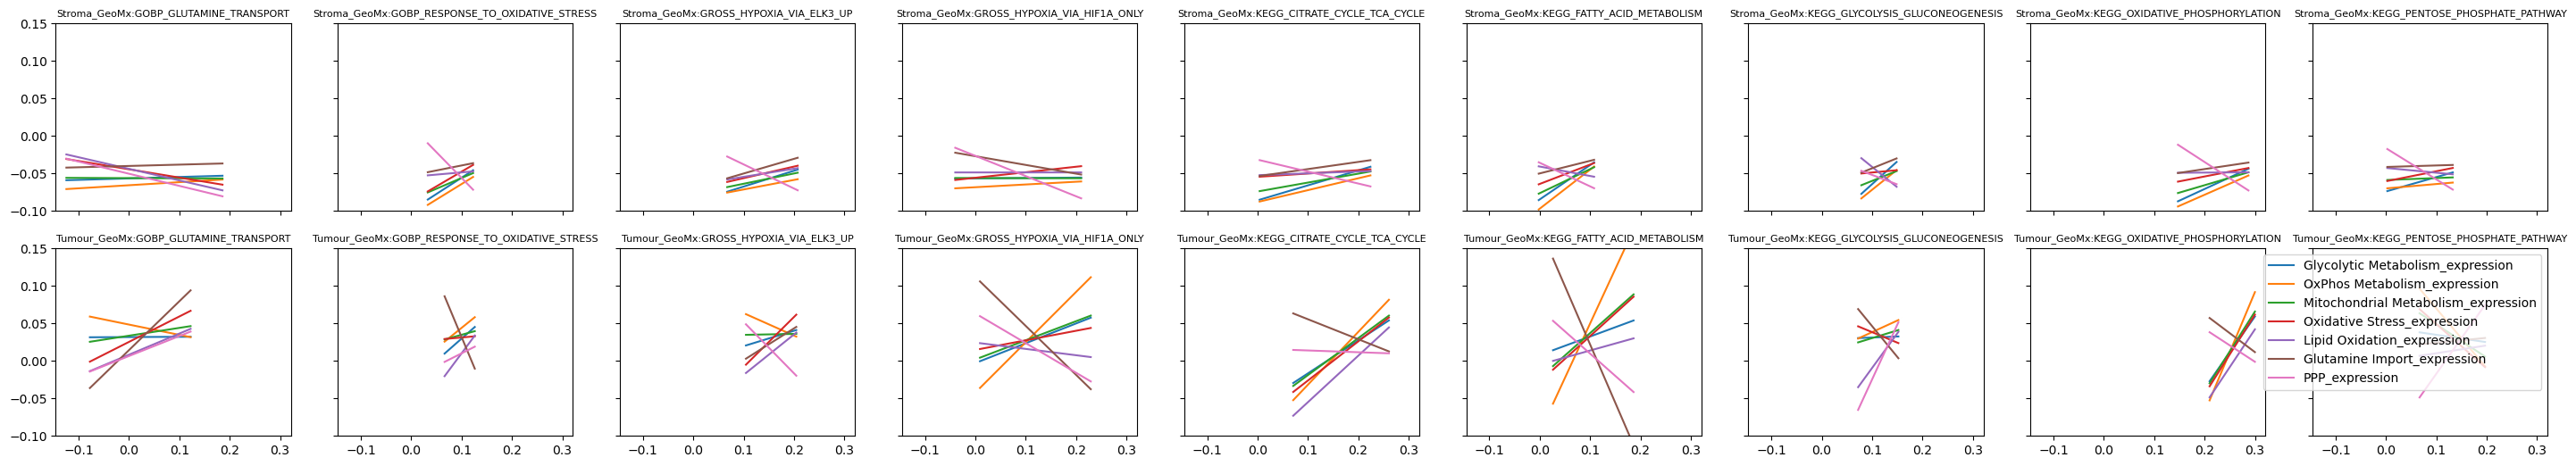

In [ ]:
# Plot regression slopes

fig, ax = plt.subplots(ncols=len(geomx_pathways), nrows=2, figsize=(4*len(geomx_pathways), 3*2), sharex=True, sharey=True)
for k, type_ in enumerate(['Stroma', 'Tumour']):
    for i, geomx_pathway in enumerate(geomx_pathways):
        for j, pcf_pathway in enumerate(pcf_pathways):
            #if (geomx_pathway, pcf_pathway) not in pairs:
            #    continue
            x = merged.loc[merged['Segment'] == type_, geomx_pathway]
            y = merged.loc[merged['Segment'] == type_, pcf_pathway]
            y = y.loc[x.index.intersection(y.index)]
            x = x.loc[x.index.intersection(y.index)]
            x, y = x.values, y.values
            res = scipy.stats.linregress(x, y)
            x = np.arange(min(x), max(x), 0.01)

            ax[k,i].plot(x, res.intercept + res.slope*x, '-', label=pcf_pathway)
            ax[k,i].set_title(type_ + '_' + geomx_pathway, fontsize=8)
            ax[k,i].set_ylim(-0.1, 0.15)
            if (k == 1) and (i == len(geomx_pathways)-1):
                ax[k,i].legend()
plt.savefig('PCF_GeoMx_Correlation.svg')
plt.plot()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


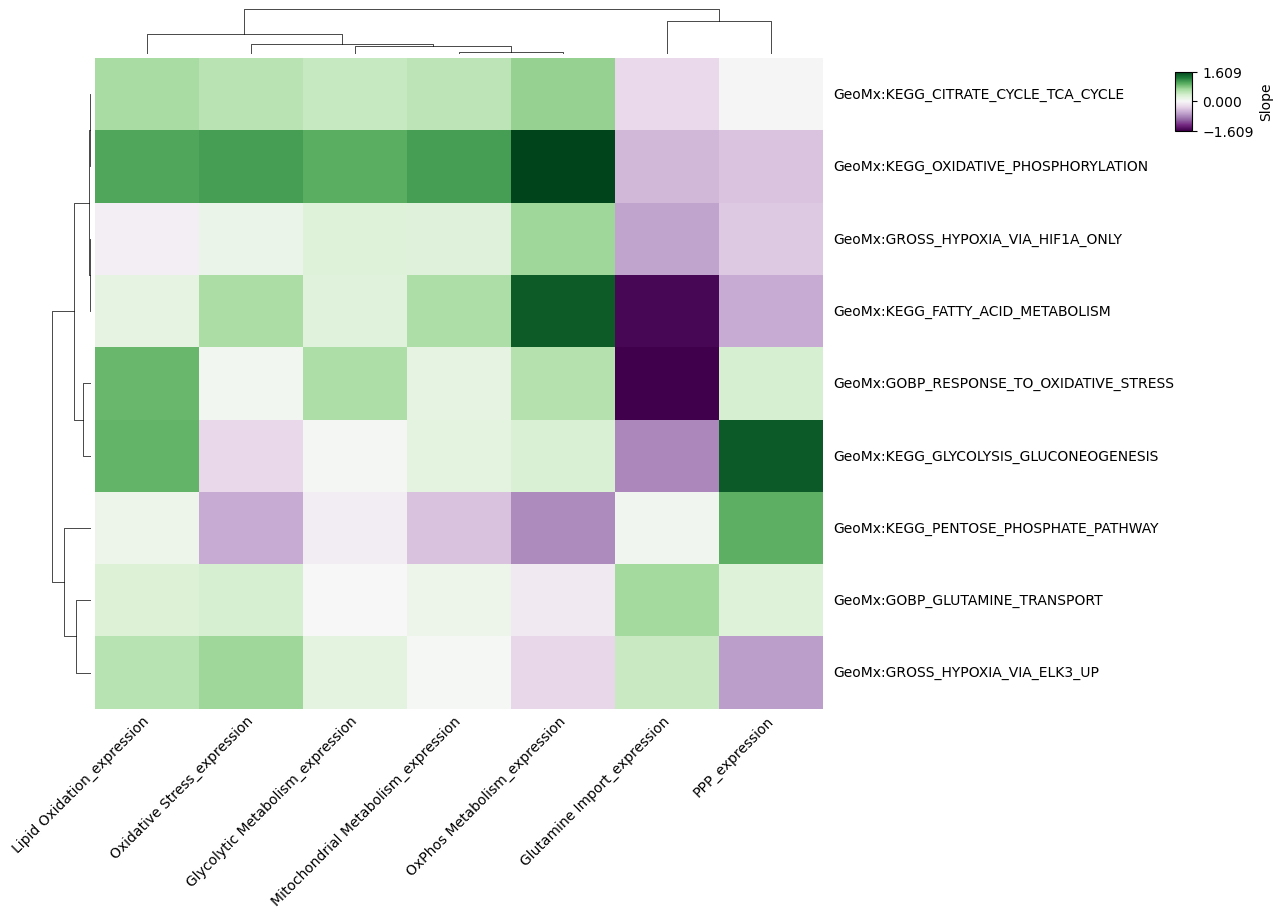

In [ ]:
# Linear Regression slopes, rerun with "Stroma"

SEGMENT = 'Tumour'

rows = []
for geomx_pathway in geomx_pathways:
    for pcf_pathway in pcf_pathways:
        sub = (merged.loc[merged['Segment'] == SEGMENT, [geomx_pathway, pcf_pathway]]
                     .dropna())
        if len(sub) < 3:
            rows.append([geomx_pathway, pcf_pathway, np.nan])
            continue
        res = scipy.stats.linregress(sub[geomx_pathway].values,
                                     sub[pcf_pathway].values)
        rows.append([geomx_pathway, pcf_pathway, res.slope])

slope_df = (pd.DataFrame(rows, columns=['GeoMx', 'PCF', 'Slope'])
              .pivot(index='GeoMx', columns='PCF', values='Slope'))

# Plot limits
vmax = np.nanmax(np.abs(slope_df.values))

plt.figure(figsize=(10, 8))
cm = ClusterMapPlotter(
    data=slope_df,
    cmap='PRGn',
    vmin=-vmax, vmax=vmax,
    row_cluster=True,
    col_cluster=True,
    row_dendrogram=True,
    col_dendrogram=True,
    show_rownames=True,
    show_colnames=True,
    label='Slope',
    tree_kws={'row_cmap': 'Set1', 'col_cmap': 'Set1'},
    xticklabels_kws={'labelrotation': 45, 'labelcolor': 'black'},
    yticklabels_kws={'labelcolor': 'black'},
)
plt.savefig(f'Figure2h_{SEGMENT.lower()}.svg', bbox_inches='tight')
plt.show()

[]

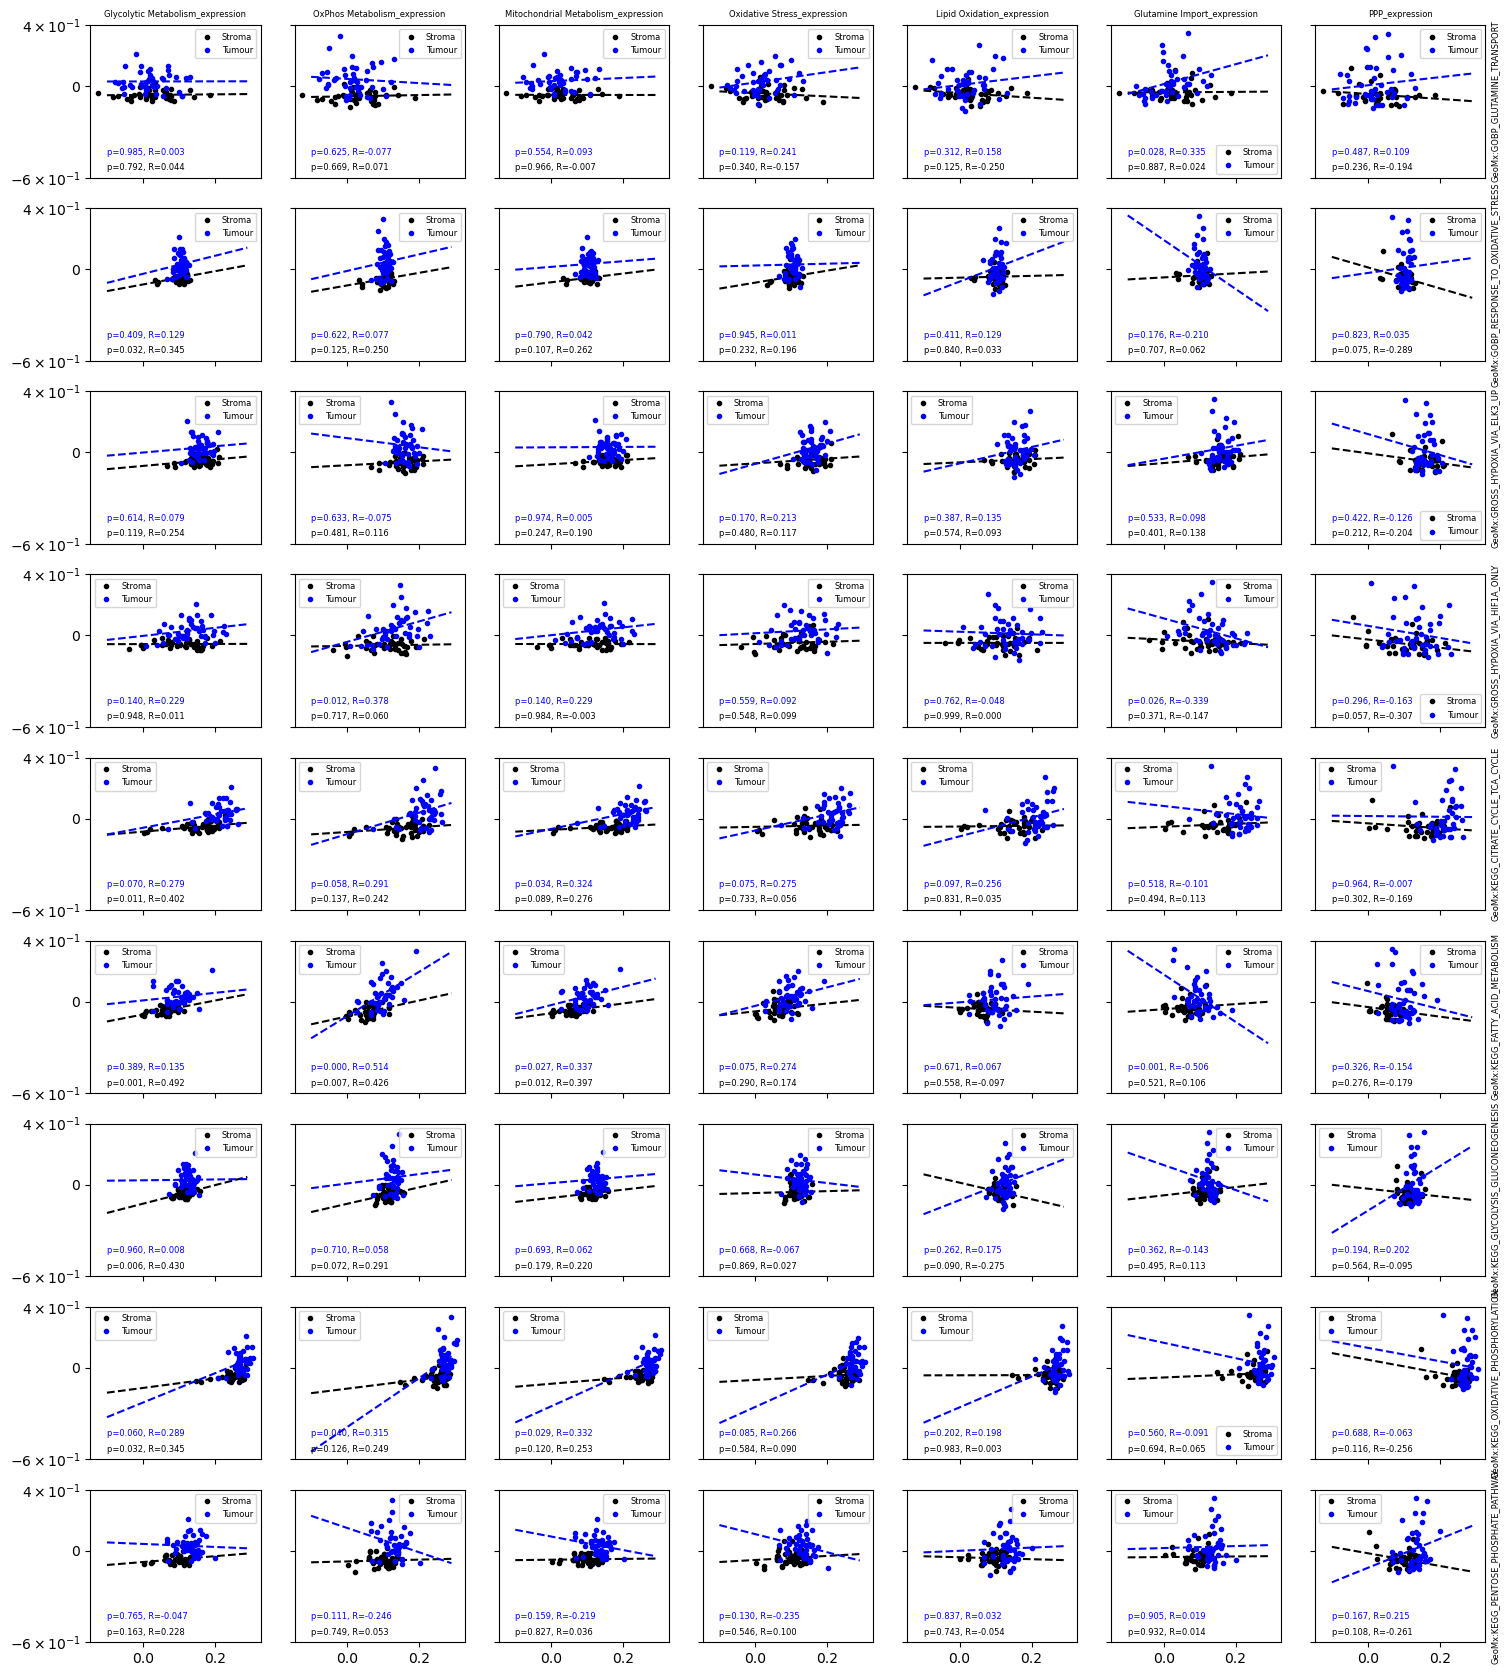

In [ ]:
fig, ax = plt.subplots(nrows=len(geomx_pathways), ncols=len(pcf_pathways), figsize=(2*len(geomx_pathways), 3*len(pcf_pathways)), sharex=True, sharey=True)
for i, geomx_pathway in enumerate(geomx_pathways):
    for j, pcf_pathway in enumerate(pcf_pathways):
        x = merged.loc[merged['Segment'] == 'Stroma', geomx_pathway]
        y = merged.loc[merged['Segment'] == 'Stroma', pcf_pathway]
        y = y.loc[x.index.intersection(y.index)]
        x = x.loc[x.index.intersection(y.index)]
        x, y = x.values, y.values

        ax[i,j].plot(x, y, 'k.', label='Stroma')
        res = scipy.stats.linregress(x, y)
        x = np.arange(-0.1, 0.3, 0.01)
        ax[i,j].plot(x, res.intercept + res.slope*x, 'k--')
        ax[i,j].text(-0.1, -0.55, f"p={res.pvalue:.3f}, R={res.rvalue:.3f}", color='k', fontsize=6)

        
        x = merged.loc[merged['Segment'] == 'Tumour', geomx_pathway]
        y = merged.loc[merged['Segment'] == 'Tumour', pcf_pathway]
        y = y.loc[x.index.intersection(y.index)]
        x = x.loc[x.index.intersection(y.index)]
        x, y = x.values, y.values

        ax[i,j].plot(x, y, 'b.', label='Tumour')
        ax[i,j].legend(fontsize=6)
        if i == 0:
            ax[i,j].set_title(pcf_pathway, fontsize=6)
        if j == len(pcf_pathways)-1:
            ax[i,j].set_ylabel(geomx_pathway, fontsize=6)
            ax[i,j].yaxis.set_label_position("right")
        res = scipy.stats.linregress(x, y)
        x = np.arange(-0.1, 0.3, 0.01)
        ax[i,j].plot(x, res.intercept + res.slope*x, 'b--')
        ax[i,j].text(-0.1, -0.45, f"p={res.pvalue:.3f}, R={res.rvalue:.3f}", color='b', fontsize=6)
        ax[i,j].set_yscale('symlog')
        ax[i,j].set_ylim(-0.6, 0.4)
plt.savefig('SupplementaryFigure_2.svg')
plt.plot()

# Correlate with MESA Neighbourhoods

In [21]:
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

In [ ]:
# Get the expression neighbourhood means across the pseudobulked segments

df_prot_neigh = pd.get_dummies(adata_geomx_overlaps.obs[['patientID', 'broad_cellsegment', 'protein_exp_nb']], columns=['protein_exp_nb']).groupby(by=['patientID', 'broad_cellsegment']).mean().reset_index()
df_prot_neigh

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_32290/3431206493.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prot_neigh = pd.get_dummies(adata_geomx_overlaps.obs[['patientID', 'broad_cellsegment', 'protein_exp_nb']], columns=['protein_exp_nb']).groupby(by=['patientID', 'broad_cellsegment']).mean().reset_index()


,patientID,broad_cellsegment,protein_exp_nb_Glutamineimport_PPP,protein_exp_nb_Hypoxic,protein_exp_nb_Hypoxic_glutamineimport,protein_exp_nb_Hypoxic_glutamineimport_PPP,protein_exp_nb_Lipid_oxidation,protein_exp_nb_Oxphos,protein_exp_nb_low,protein_exp_nb_pNRFhiSDHAhi_CPTA1lo
0,B11,Stroma,0.034090,0.000000,0.000886,0.115634,0.000000,0.000000,0.849390,0.000000
1,B11,Tumour,0.109193,0.000000,0.001303,0.816464,0.000000,0.000000,0.072714,0.000326
2,B12,Stroma,0.000000,0.000000,0.009697,0.000000,0.000000,0.000000,0.990303,0.000000
3,B12,Tumour,0.000000,0.000000,0.009592,0.000000,0.000000,0.000000,0.990408,0.000000
4,B14,Stroma,0.000000,0.187625,0.038796,0.000000,0.001505,0.014548,0.756522,0.001003
...,...,...,...,...,...,...,...,...,...,...
83,B82,Tumour,0.013121,0.001112,0.001446,0.000000,0.000000,0.136662,0.538975,0.308685
84,B83,Stroma,0.000000,0.120561,0.026120,0.000000,0.007529,0.000558,0.831753,0.013478
85,B83,Tumour,0.000000,0.735652,0.057188,0.000000,0.002870,0.003758,0.178737,0.021796
86,B85,Stroma,0.000000,0.002941,0.001826,0.000000,0.028905,0.000406,0.869270,0.096653


In [ ]:
# Merge the datasets

merged_prot = pd.merge(df_geomx, df_prot_neigh, left_on=['patientid', 'Segment'], right_on=['patientID', 'broad_cellsegment']).set_index(['patientid', 'Segment'])
prot_pathways = merged_prot.columns[~merged_prot.columns.str.contains('GeoMx:')]
prot_pathways = prot_pathways[(prot_pathways != 'patientID') & (prot_pathways != 'broad_cellsegment')]
merged_prot

GeoMx:GOBP_GLUTAMINE_TRANSPORT  \
patientid Segment                                   
B11       Stroma                         0.014131   
          Tumour                         0.020322   
B12       Stroma                         0.008898   
          Tumour                         0.036832   
B14       Tumour                        -0.008022   
...                                           ...   
B82       Tumour                         0.014964   
B83       Stroma                        -0.012101   
          Tumour                         0.026824   
B85       Stroma                         0.023978   
          Tumour                         0.099249   

                   GeoMx:GOBP_RESPONSE_TO_OXIDATIVE_STRESS  \
patientid Segment                                            
B11       Stroma                                  0.120846   
          Tumour                                  0.110501   
B12       Stroma                                  0.092101   
          Tumour                                  0.090653   
B14       Tumour                                  0.103345   
...                                                    ...   
B82       Tumour                                  0.093351   
B83       Stroma                                  0.097206   
          Tumour                                  0.099684   
B85       Stroma                                  0.096372   
          Tumour                                  0.098904   

                   GeoMx:GROSS_HYPOXIA_VIA_ELK3_UP  \
patientid Segment                                    
B11       Stroma                          0.172359   
          Tumour                          0.162873   
B12       Stroma                          0.159811   
          Tumour                          0.156965   
B14       Tumour                          0.175323   
...                                            ...   
B82       Tumour                          0.151314   
B83       Stroma                          0.140262   
          Tumour                          0.145214   
B85       Stroma                          0.134457   
          Tumour                          0.151732   

                   GeoMx:GROSS_HYPOXIA_VIA_HIF1A_ONLY  \
patientid Segment                                       
B11       Stroma                             0.177889   
          Tumour                             0.127538   
B12       Stroma                            -0.000368   
          Tumour                             0.056225   
B14       Tumour                             0.162579   
...                                               ...   
B82       Tumour                             0.165861   
B83       Stroma                             0.119930   
          Tumour                             0.121357   
B85       Stroma                             0.158969   
          Tumour                             0.097213   

                   GeoMx:KEGG_CITRATE_CYCLE_TCA_CYCLE  \
patientid Segment                                       
B11       Stroma                             0.189116   
          Tumour                             0.241993   
B12       Stroma                             0.151330   
          Tumour                             0.218971   
B14       Tumour                             0.209223   
...                                               ...   
B82       Tumour                             0.181501   
B83       Stroma                             0.107217   
          Tumour                             0.172515   
B85       Stroma                             0.137442   
          Tumour                             0.263514   

                   GeoMx:KEGG_FATTY_ACID_METABOLISM  \
patientid Segment                                     
B11       Stroma                           0.076819   
          Tumour                           0.076802   
B12       Stroma                           0.050875   
          Tumour                           0.102725   
B14  

[]

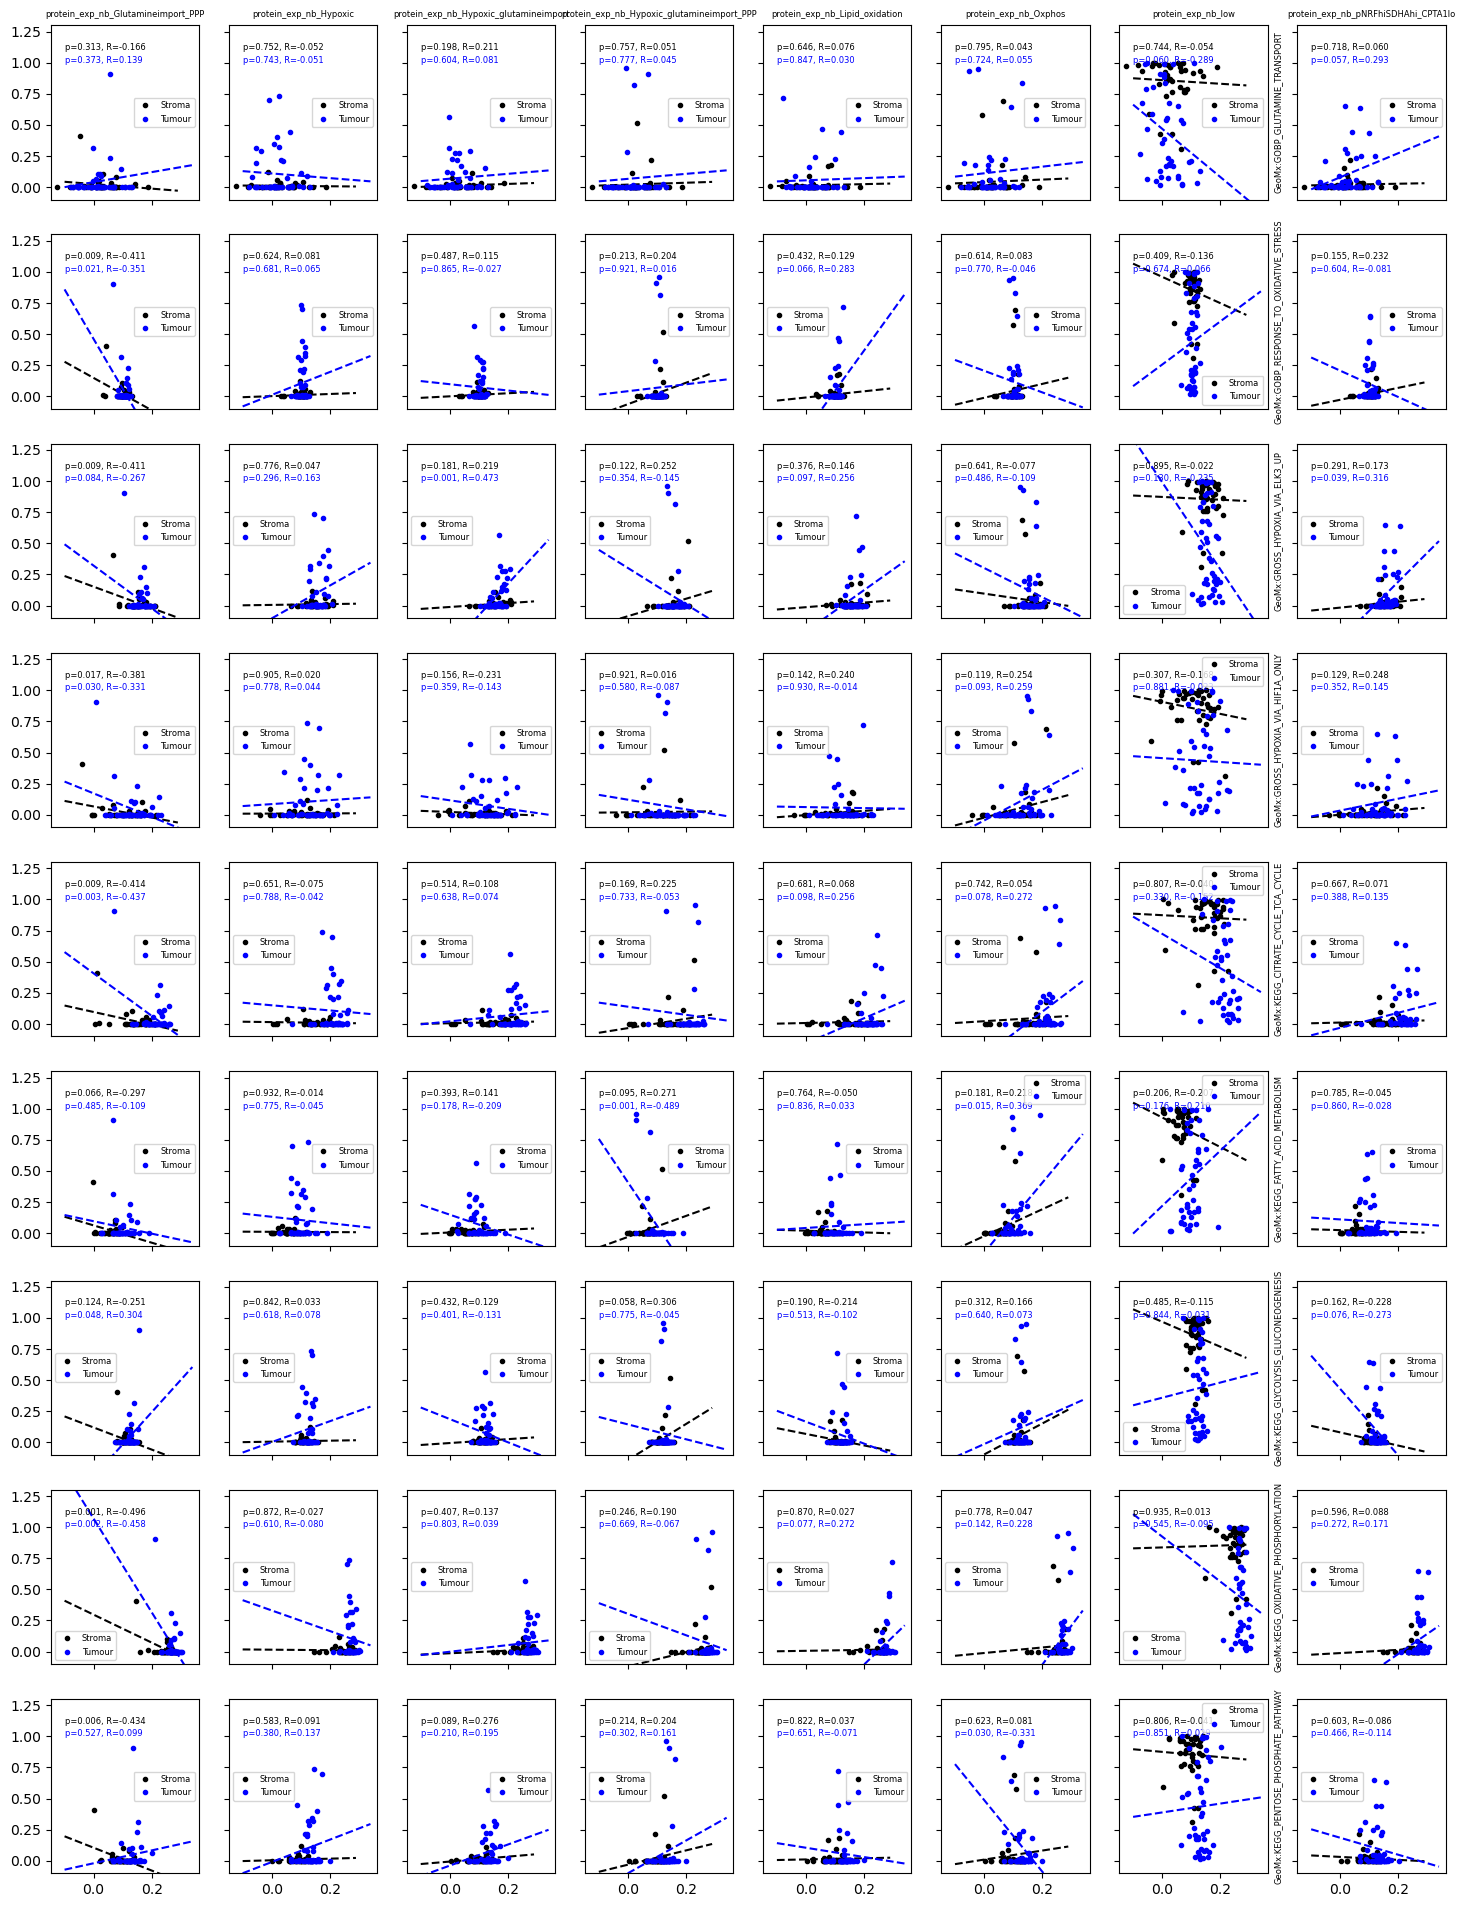

In [ ]:
fig, ax = plt.subplots(nrows=len(geomx_pathways), ncols=len(prot_pathways), figsize=(2*len(geomx_pathways), 3*len(prot_pathways)), sharex=True, sharey=True)
for i, geomx_pathway in enumerate(geomx_pathways):
    for j, pcf_pathway in enumerate(prot_pathways):
        x = merged_prot.loc[merged_prot.index.get_level_values('Segment') == 'Stroma', geomx_pathway]
        y = merged_prot.loc[merged_prot.index.get_level_values('Segment') == 'Stroma', pcf_pathway]
        y = y.loc[x.index.intersection(y.index)]
        x = x.loc[x.index.intersection(y.index)]
        x, y = x.values, y.values

        ax[i,j].plot(x, y, 'k.', label='Stroma')
        res = scipy.stats.linregress(x, y)
        x = np.arange(-0.1, 0.3, 0.01)
        ax[i,j].plot(x, res.intercept + res.slope*x, 'k--')
        ax[i,j].text(-0.1, 1.1, f"p={res.pvalue:.3f}, R={res.rvalue:.3f}", color='k', fontsize=6)

        
        x = merged_prot.loc[merged_prot.index.get_level_values('Segment') == 'Tumour', geomx_pathway]
        y = merged_prot.loc[merged_prot.index.get_level_values('Segment') == 'Tumour', pcf_pathway]
        y = y.loc[x.index.intersection(y.index)]
        x = x.loc[x.index.intersection(y.index)]
        x, y = x.values, y.values

        ax[i,j].plot(x, y, 'b.', label='Tumour')
        ax[i,j].legend(fontsize=6)
        if i == 0:
            ax[i,j].set_title(pcf_pathway, fontsize=6)
        if j == len(pcf_pathways)-1:
            ax[i,j].set_ylabel(geomx_pathway, fontsize=6)
            ax[i,j].yaxis.set_label_position("right")
        res = scipy.stats.linregress(x, y)
        x = np.arange(-0.1, 0.35, 0.01)
        ax[i,j].plot(x, res.intercept + res.slope*x, 'b--')
        ax[i,j].text(-0.1, 1.0, f"p={res.pvalue:.3f}, R={res.rvalue:.3f}", color='b', fontsize=6)
        ax[i,j].set_ylim(-0.1, 1.3)
        #ax[i,j].set_yscale('log')

plt.savefig('SupplementaryFigure3.svg')
plt.plot()

In [ ]:
def create_heatmap():
    df_pcf_ = (adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', 'protein_exp_nb']).size() / adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', ]).size()).reset_index()
    df_pcf_ = df_pcf_.rename(columns={'nb_tumour_nontumour_50_2': 'Segment', 0: 'values'})
    metabolic_fraction_wide = df_pcf_.pivot(
        index=["patientID", "Segment"],
        columns="protein_exp_nb",
        values='values',
    )
    metabolic_fraction_wide.columns = metabolic_fraction_wide.columns.astype(object)
    return pd.merge(df_geomx, metabolic_fraction_wide, left_on=['patientid', 'Segment'], right_on=['patientID', 'Segment']).set_index(['patientid', ])

merged = create_heatmap()
merged

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_59335/3328390044.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pcf_ = (adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', 'protein_exp_nb']).size() / adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', ]).size()).reset_index()
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_59335/3328390044.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pcf_ = (adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', 'protein_exp_nb']).size() / adata.obs.groupby(by=['patientID', 'nb_tumour_nontumour_50_2', ]).si

,Segment,GeoMx:GOBP_GLUTAMINE_TRANSPORT,GeoMx:GOBP_RESPONSE_TO_OXIDATIVE_STRESS,GeoMx:GROSS_HYPOXIA_VIA_ELK3_UP,GeoMx:GROSS_HYPOXIA_VIA_HIF1A_ONLY,GeoMx:KEGG_CITRATE_CYCLE_TCA_CYCLE,GeoMx:KEGG_FATTY_ACID_METABOLISM,GeoMx:KEGG_GLYCOLYSIS_GLUCONEOGENESIS,GeoMx:KEGG_OXIDATIVE_PHOSPHORYLATION,GeoMx:KEGG_PENTOSE_PHOSPHATE_PATHWAY,Glutamineimport_PPP,Hypoxic,Hypoxic_glutamineimport,Hypoxic_glutamineimport_PPP,Lipid_oxidation,Oxphos,low,pNRFhiSDHAhi_CPTA1lo
patientid,,,,,,,,,,,,,,,,,,
B11,Stroma,0.014131,0.120846,0.172359,0.177889,0.189116,0.076819,0.115970,0.265719,0.138624,0.026784,0.000000,0.000805,0.055763,0.000000,0.000000,0.916648,0.000000
B11,Tumour,0.020322,0.110501,0.162873,0.127538,0.241993,0.076802,0.114778,0.276645,0.163020,0.111044,0.000000,0.001355,0.825190,0.000000,0.000000,0.062109,0.000301
B12,Stroma,0.008898,0.092101,0.159811,-0.000368,0.151330,0.050875,0.078579,0.248727,0.022853,0.000000,0.000000,0.000497,0.000000,0.000000,0.000000,0.999503,0.000000
B12,Tumour,0.036832,0.090653,0.156965,0.056225,0.218971,0.102725,0.122005,0.282634,0.151772,0.000000,0.000000,0.011246,0.000000,0.000000,0.000000,0.988754,0.000000
B14,Tumour,-0.008022,0.103345,0.175323,0.162579,0.209223,0.071364,0.139729,0.258834,0.173991,0.000000,0.676815,0.118604,0.000000,0.000099,0.042047,0.156486,0.005950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B82,Tumour,0.014964,0.093351,0.151314,0.165861,0.181501,0.113537,0.120738,0.264723,0.084037,0.012890,0.001386,0.002079,0.000000,0.000000,0.194872,0.402079,0.386694
B83,Stroma,-0.012101,0.097206,0.140262,0.119930,0.107217,0.081486,0.132880,0.232125,0.101839,0.000000,0.019408,0.016205,0.000000,0.006124,0.000000,0.953929,0.004334
B83,Tumour,0.026824,0.099684,0.145214,0.121357,0.172515,0.124603,0.134973,0.267543,0.144641,0.000000,0.802300,0.064005,0.000000,0.003924,0.004127,0.097361,0.028281


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


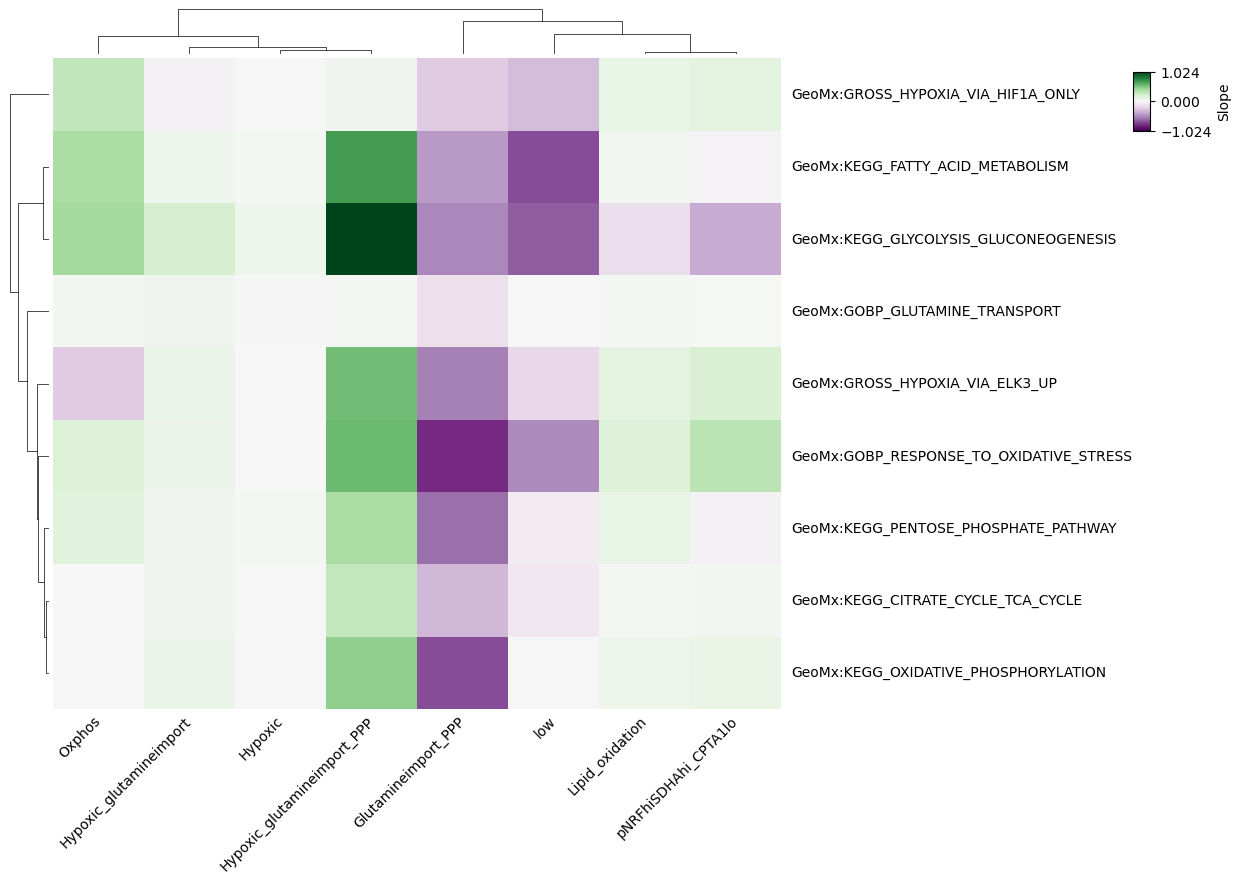

In [ ]:
SEGMENT = 'Stroma'

rows = []
for geomx_pathway in geomx_pathways:
    for pcf_pathway in adata.obs['protein_exp_nb'].unique():
        sub = (merged.loc[merged['Segment'] == SEGMENT, [geomx_pathway, pcf_pathway]]
                     .dropna())
        if len(sub) < 3:
            rows.append([geomx_pathway, pcf_pathway, np.nan])
            continue
        res = scipy.stats.linregress(sub[geomx_pathway].values,
                                     sub[pcf_pathway].values)
        rows.append([geomx_pathway, pcf_pathway, res.slope])

slope_df = (pd.DataFrame(rows, columns=['GeoMx', 'PCF', 'Slope'])
              .pivot(index='GeoMx', columns='PCF', values='Slope'))

vmax = np.nanmax(np.abs(slope_df.values))

plt.figure(figsize=(10, 8))
cm = ClusterMapPlotter(
    data=slope_df,
    cmap='PRGn',
    vmin=-vmax, vmax=vmax,
    row_cluster=True,
    col_cluster=True,
    row_dendrogram=True,
    col_dendrogram=True,
    show_rownames=True,
    show_colnames=True,
    label='Slope',
    tree_kws={'row_cmap': 'Set1', 'col_cmap': 'Set1'},
    xticklabels_kws={'labelrotation': 45, 'labelcolor': 'black'},
    yticklabels_kws={'labelcolor': 'black'},
)
plt.savefig(f'corr_geomx_pcfnbs_{SEGMENT.lower()}.svg', bbox_inches='tight')
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


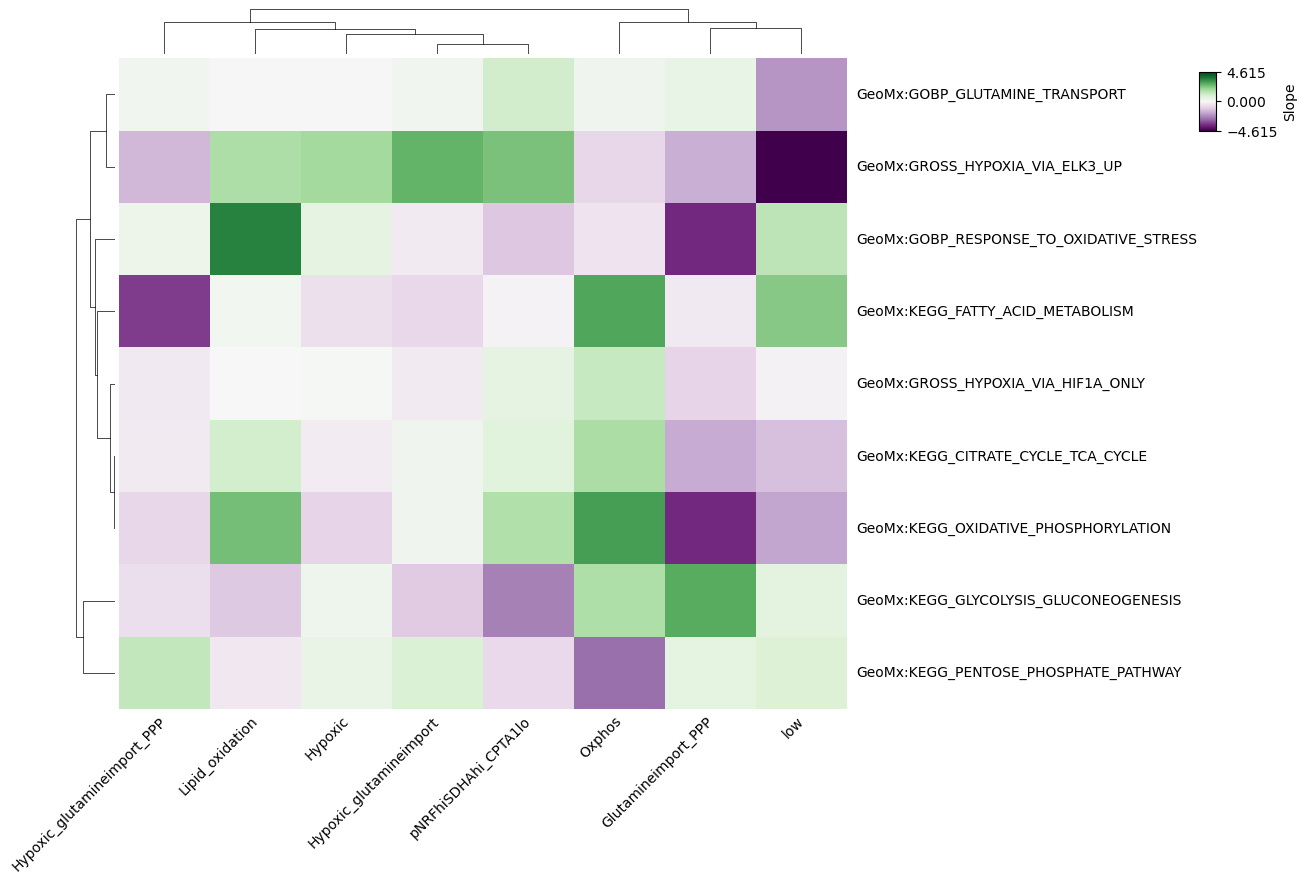

In [ ]:
SEGMENT = 'Tumour'

rows = []
for geomx_pathway in geomx_pathways:
    for pcf_pathway in adata.obs['protein_exp_nb'].unique():
        sub = (merged.loc[merged['Segment'] == SEGMENT, [geomx_pathway, pcf_pathway]]
                     .dropna())
        if len(sub) < 3:
            rows.append([geomx_pathway, pcf_pathway, np.nan])
            continue
        res = scipy.stats.linregress(sub[geomx_pathway].values,
                                     sub[pcf_pathway].values)
        rows.append([geomx_pathway, pcf_pathway, res.slope])

slope_df = (pd.DataFrame(rows, columns=['GeoMx', 'PCF', 'Slope'])
              .pivot(index='GeoMx', columns='PCF', values='Slope'))

vmax = np.nanmax(np.abs(slope_df.values))

plt.figure(figsize=(10, 8))
cm = ClusterMapPlotter(
    data=slope_df,
    cmap='PRGn',
    vmin=-vmax, vmax=vmax,
    row_cluster=True,
    col_cluster=True,
    row_dendrogram=True,
    col_dendrogram=True,
    show_rownames=True,
    show_colnames=True,
    label='Slope',
    tree_kws={'row_cmap': 'Set1', 'col_cmap': 'Set1'},
    xticklabels_kws={'labelrotation': 45, 'labelcolor': 'black'},
    yticklabels_kws={'labelcolor': 'black'},
)
plt.savefig(f'corr_geomx_pcfnbs_{SEGMENT.lower()}.svg', bbox_inches='tight')
plt.show()